# Чекпоинт 6 · Deep Learning эксперименты

**Что в ноутбуке:**

1. Подготовка датасета и временной разметки - как в чекпоинтах 3-5.
2. **MLP** на плоских фичах - табличный DL-baseline.
3. **1D-CNN**, **LSTM**, **mini-Transformer** на временных окнах
   (sliding window длины 10 дней).
4. **FinBERT** sentiment-фича на квартальной выборке заголовков GDELT
   (ProsusAI/finbert, zero-shot). Сравнение с GDELT-tone.
5. Сводная таблица **архитектура х фичесет х время х качество**.
6. Общий бенчмарк: baseline (чекпоинт 3) -> лучшие ML (чекпоинт 5) -> лучшие DL (чекпоинт 6).
7. выводы.

**Опорная литература:**
* Hashamia & Maldonado (2025), [arXiv:2508.20707](https://arxiv.org/abs/2508.20707) - FinBERT/FastText/LLaMA ансамбль для direction WTI.
* Gurgul, Lessmann, Härdle (2023), [arXiv:2311.14759](https://arxiv.org/abs/2311.14759) - LSTM + NLP для криптовалют.
* Ghali et al. (2025), [arXiv:2508.06497](https://arxiv.org/abs/2508.06497) - dual-stream LSTM с attention для commodity-shock.
* Kaplan et al. (2023), [arXiv:2305.06140](https://arxiv.org/abs/2305.06140) - CrudeBERT (домен-fine-tune FinBERT под нефть).
* Vaswani et al. (2017) - Transformer; используется в mini-encoder.

## 1. Импорты и стиль

In [ ]:
import sys, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from sklearn.preprocessing import StandardScaler, LabelEncoder

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.config import get_data_config, PROJECT_ROOT as P_ROOT
from src.features.labels import build_target_frame
from src.features.technical import build_price_features, PRICE_FEATURE_COLS
from src.features.text_signals import daily_gdelt_signals
from src.features.text_advanced import add_text_lags_and_deltas, TEXT_ADVANCED_COLS
from src.features.cross_asset import brent_wti_spread, CROSS_ASSET_OIL_COLS
from src.features.clustering import fit_regime_clusters, assign_regime
from src.models.metrics import score, compare_results, CLASSES
from src.models.dl_models import make_model
from src.models.dl_training import TrainConfig, build_sequences, train_model

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 4.5)
warnings.filterwarnings("ignore")

CFG = get_data_config()
ASSETS = CFG["assets"]
RANDOM_STATE = 42
SPLIT_DATE = pd.Timestamp("2024-01-01")
TARGET_CFG = CFG["target"]
TOPIC_OF = {"brent": "oil", "wti": "oil", "btc": "btc"}
SEQ_LEN = 10  # окно последовательности для CNN/LSTM/Transformer

DEVICE = "cpu"  # сохраняем CPU для воспроизводимости
print("torch:", torch.__version__, "device:", DEVICE)

torch: 2.4.1 device: cpu


## 2. Сборка датасета и FinBERT-блок

Воспроизводим pipeline из чекпоинта 5: цены -> таргет -> технические индикаторы ->
GDELT (volume + tone) -> лаги/дельты -> cross-asset спред (для нефти) ->
кластерный режим. Поверх этого подключаем FinBERT-агрегаты по дням,
заранее посчитанные отдельным скриптом (`src/features/finbert.py`).

In [2]:
def _safe_filename(t): return t.replace("=", "_").replace("/", "_")

def load_prices_one(key):
    a = ASSETS[key]
    df = pd.read_parquet(P_ROOT / CFG["prices"]["cache_dir"] / f"{_safe_filename(a['ticker'])}.parquet")
    df.index = pd.to_datetime(df.index).tz_localize(None)
    return df

raw_prices = {k: load_prices_one(k) for k in ASSETS}

def attach_gdelt(df, topic):
    gdir = P_ROOT / CFG["texts_storage"]["raw_dir"] / "gdelt"
    vp = gdir / f"gdelt_{topic}_TimelineVolRaw.parquet"
    tp = gdir / f"gdelt_{topic}_TimelineTone.parquet"
    if not (vp.exists() and tp.exists()):
        return df
    sig = daily_gdelt_signals(pd.read_parquet(vp), pd.read_parquet(tp))
    sig.index = pd.to_datetime(sig.index).tz_localize(None)
    out = df.copy()
    out.index = pd.to_datetime(out.index).normalize()
    sig.index = pd.to_datetime(sig.index).normalize()
    return out.join(sig, how="left")

def attach_finbert(df, topic):
    """Подключает FinBERT-агрегаты, если они посчитаны."""
    cache = P_ROOT / "data" / "processed" / f"finbert_{topic}_daily.parquet"
    if not cache.exists():
        return df
    fb = pd.read_parquet(cache)
    fb.index = pd.to_datetime(fb.index).tz_localize(None).normalize()
    out = df.copy()
    out.index = pd.to_datetime(out.index).normalize()
    return out.join(fb, how="left")

oil_spread = brent_wti_spread(raw_prices["brent"], raw_prices["wti"])
oil_spread.index = pd.to_datetime(oil_spread.index).normalize()

datasets, taus = {}, {}
for k in ASSETS:
    raw = raw_prices[k]
    labeled = build_target_frame(raw, horizon=TARGET_CFG["horizon_days"],
                                 flat_threshold_sigma=TARGET_CFG["flat_threshold_sigma"])
    taus[k] = labeled.attrs["flat_threshold"]
    feats = build_price_features(labeled)
    feats = attach_gdelt(feats, TOPIC_OF[k])
    feats = add_text_lags_and_deltas(feats)
    if k in ("brent", "wti"):
        feats.index = pd.to_datetime(feats.index).normalize()
        feats = feats.join(oil_spread, how="left")
    feats = attach_finbert(feats, TOPIC_OF[k])
    datasets[k] = feats
    fb_cols = [c for c in feats.columns if c.startswith("finbert_")]
    print(f"{k:6s} | rows {len(feats):5d} | cols {feats.shape[1]:3d} | tau {taus[k]:.5f}  "
          f"| finbert_cols: {fb_cols}")

brent  | rows  2102 | cols  61 | tau 0.00263  | finbert_cols: ['finbert_pos_share', 'finbert_neg_share', 'finbert_neutral_share', 'finbert_compound', 'finbert_n_texts']
wti    | rows  2101 | cols  61 | tau 0.00303  | finbert_cols: ['finbert_pos_share', 'finbert_neg_share', 'finbert_neutral_share', 'finbert_compound', 'finbert_n_texts']
btc    | rows  3052 | cols  53 | tau 0.00340  | finbert_cols: []


**Режим k-means.** Обучаем кластеризатор на train, применяем к test -
без data leakage, как и в чекпоинте 5.

In [3]:
REGIME_FEATURES = ["rv_21", "article_count_z21"]
for k, df in datasets.items():
    have = [c for c in REGIME_FEATURES if c in df.columns]
    if len(have) < 2:
        continue
    train_part = df.loc[df.index < SPLIT_DATE]
    km, sc = fit_regime_clusters(train_part, have, n_clusters=3, random_state=RANDOM_STATE)
    df["regime"] = assign_regime(df, have, km, sc)
print("regime готов")

regime готов


## 3. FinBERT vs GDELT-Tone

GDELT даёт `avg_tone` - усреднённый sentiment по WordNet-словарю.
FinBERT - BERT-base, дообученный на Financial PhraseBank (то есть
на специально размеченных финансовых текстах). Сравниваем эти две
метрики на пересечении дат: если они положительно коррелированы,
говорят примерно об одном и том же; если корреляция слабая или
отрицательная - FinBERT несёт новую информацию поверх tone.

brent: пересечение по датам 9 дней
                  avg_tone  finbert_compound  finbert_n_texts
avg_tone             1.000            -0.540            0.295
finbert_compound    -0.540             1.000           -0.431
finbert_n_texts      0.295            -0.431            1.000


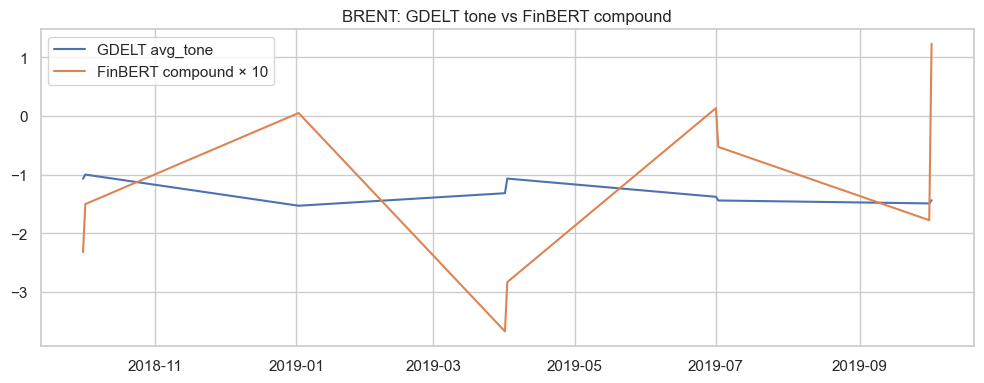

In [4]:
for k in ("brent",):
    df = datasets[k]
    if "finbert_compound" not in df.columns:
        print(f"{k}: FinBERT-данных нет - пропуск")
        continue
    sub = df[["avg_tone", "finbert_compound", "finbert_n_texts"]].dropna()
    if sub.empty:
        print(f"{k}: пересечение по датам пустое")
        continue
    print(f"{k}: пересечение по датам {len(sub)} дней")
    print(sub.corr().round(3).to_string())

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(sub.index, sub["avg_tone"], label="GDELT avg_tone")
    ax.plot(sub.index, sub["finbert_compound"] * 10, label="FinBERT compound × 10")
    ax.set_title(f"{k.upper()}: GDELT tone vs FinBERT compound")
    ax.legend(); plt.tight_layout(); plt.show()

## 4. Подготовка X, y: плоский и оконный варианты

Для MLP - плоский (B, F). Для CNN/LSTM/Transformer - окно (B, T, F),
T = 10 дней. Сначала собираем плоский, потом из него - окна.

In [ ]:
BASE_FEATURES = list(PRICE_FEATURE_COLS)
TEXT_BASIC    = ["article_count", "article_norm", "avg_tone"]
TEXT_ADV      = list(TEXT_ADVANCED_COLS)
CROSS_ASSET   = list(CROSS_ASSET_OIL_COLS)
EXTRA         = ["regime"]
FINBERT_COLS  = ["finbert_pos_share", "finbert_neg_share", "finbert_neutral_share",
                 "finbert_compound", "finbert_n_texts"]

FEAT_SETS = {
    "price_only":         BASE_FEATURES,
    "full_no_finbert":    BASE_FEATURES + TEXT_BASIC + TEXT_ADV + CROSS_ASSET + EXTRA,
    "full_with_finbert":  BASE_FEATURES + TEXT_BASIC + TEXT_ADV + CROSS_ASSET + EXTRA + FINBERT_COLS,
}

LABEL_ORDER = list(CLASSES)
le = LabelEncoder().fit(LABEL_ORDER)

def build_flat_xy(df, feature_cols):
    cols = [c for c in feature_cols if c in df.columns]
    sub = df[cols + ["target"]].dropna()
    Xtr = sub.loc[sub.index < SPLIT_DATE, cols].values
    Xte = sub.loc[sub.index >= SPLIT_DATE, cols].values
    ytr = sub.loc[sub.index < SPLIT_DATE, "target"]
    yte = sub.loc[sub.index >= SPLIT_DATE, "target"]
    return Xtr, Xte, ytr, yte, cols

def standardize_train_apply(Xtr, Xte):
    """Скейлинг подгоняем на train, применяем к test."""
    sc = StandardScaler().fit(Xtr)
    return sc.transform(Xtr).astype(np.float32), sc.transform(Xte).astype(np.float32), sc

# Соберём всё в structuration по (asset, feat_set, view)
prepared = {}
for k, df in datasets.items():
    prepared[k] = {}
    for name, cols in FEAT_SETS.items():
        Xtr, Xte, ytr, yte, used = build_flat_xy(df, cols)
        # Пропускаем, если фичей мало или с FinBERT слишком много пропусков
        if len(used) == 0 or len(Xtr) < 200 or len(Xte) < 50:
            continue
        Xtr_s, Xte_s, sc = standardize_train_apply(Xtr, Xte)
        ytr_e = le.transform(ytr).astype(np.int64)
        yte_e = le.transform(yte).astype(np.int64)
        # Окна
        Xtr_seq, ytr_seq = build_sequences(Xtr_s, ytr_e, SEQ_LEN)
        Xte_seq, yte_seq = build_sequences(Xte_s, yte_e, SEQ_LEN)
        prepared[k][name] = dict(
            flat_X_tr=Xtr_s, flat_X_te=Xte_s, flat_y_tr=ytr_e, flat_y_te=yte_e,
            seq_X_tr=Xtr_seq.astype(np.float32), seq_X_te=Xte_seq.astype(np.float32),
            seq_y_tr=ytr_seq, seq_y_te=yte_seq,
            y_tr_strings=ytr, y_te_strings=yte,
            cols=used, n_features=Xtr_s.shape[1],
        )
        print(f"{k:6s} | {name:18s} | features={Xtr_s.shape[1]:3d}, "
              f"flat: tr={len(Xtr_s)} te={len(Xte_s)} | seq: tr={len(Xtr_seq)} te={len(Xte_seq)}")

brent  | price_only         | features= 24, flat: tr=1469 te=500 | seq: tr=1460 te=491
brent  | full_no_finbert    | features= 47, flat: tr=1041 te=369 | seq: tr=1032 te=360
wti    | price_only         | features= 24, flat: tr=1445 te=500 | seq: tr=1436 te=491
wti    | full_no_finbert    | features= 47, flat: tr=1018 te=369 | seq: tr=1009 te=360
btc    | price_only         | features= 24, flat: tr=2170 te=860 | seq: tr=2161 te=851


btc    | full_no_finbert    | features= 44, flat: tr=1925 te=531 | seq: tr=1916 te=522


btc    | full_with_finbert  | features= 44, flat: tr=1925 te=531 | seq: tr=1916 te=522


## 5. Обучение DL-моделей

Стратегия. Для каждого актива и каждого набора фичей обучаем четыре
архитектуры:
* **MLP** - плоский X, без окон.
* **CNN1D**, **LSTM**, **Transformer** - окна (B, T=10, F).

Гиперпараметры моделей фиксированы (см. `src/models/dl_models.py`), train -
60 эпох с early stopping по val macro-F1 (patience=8). seed=42.

Время обучения замеряем и кладём в таблицу - это требование описания
чекпойнта.

In [ ]:
def fit_dl(model_name: str, data: dict, model_kwargs: dict, label_suffix: str = "") -> dict:
    """Унифицированный fit + eval. Возвращает result-dict для агрегации."""
    cfg_tr = TrainConfig(device=DEVICE, max_epochs=60, patience=8,
                          batch_size=64, lr=1e-3, weight_decay=1e-4, seed=RANDOM_STATE)
    if model_name == "mlp":
        Xtr, Xte = data["flat_X_tr"], data["flat_X_te"]
        ytr, yte_e = data["flat_y_tr"], data["flat_y_te"]
        factory = lambda: make_model("mlp", n_features=data["n_features"], **model_kwargs)
    else:
        Xtr, Xte = data["seq_X_tr"], data["seq_X_te"]
        ytr, yte_e = data["seq_y_tr"], data["seq_y_te"]
        factory = lambda: make_model(model_name, n_features=data["n_features"],
                                     seq_len=SEQ_LEN, **model_kwargs)

    if len(Xtr) < 100 or len(Xte) < 30:
        return {"skipped": True}
    out = train_model(factory, Xtr, ytr, Xte, yte_e, cfg_tr)
    # Восстановим строковые метки для score()
    yte_strings = (data["y_te_strings"].iloc[SEQ_LEN - 1:]
                    if model_name != "mlp" else data["y_te_strings"])
    y_pred_strings = le.inverse_transform(out["y_pred"])
    r = score(yte_strings, y_pred_strings, name="placeholder")
    r.train_time_sec = out["train_time_sec"]   # type: ignore[attr-defined]
    r.n_params = out["n_params"]               # type: ignore[attr-defined]
    r.stopped_epoch = out["stopped_epoch"]     # type: ignore[attr-defined]
    r.train_loss_curve = out["train_loss_curve"]
    r.val_f1_curve = out["val_f1_curve"]
    return {"result": r}

DL_MODELS = ["mlp", "cnn", "lstm", "transformer"]
# Кастом-гиперпараметры
MODEL_KWARGS = {
    "mlp": {"dropout": 0.3},
    "cnn": {},
    "lstm": {"hidden": 32, "dropout": 0.2},
    "transformer": {"d_model": 32, "n_heads": 4, "n_layers": 2, "dropout": 0.1},
}

dl_experiments = []
for asset_key in datasets:
    for feat_set_name, data in prepared[asset_key].items():
        for model_name in DL_MODELS:
            try:
                res = fit_dl(model_name, data, MODEL_KWARGS[model_name])
                if res.get("skipped"):
                    continue
                r = res["result"]
                r.name = f"{asset_key}/{feat_set_name}/{model_name}"
                dl_experiments.append(r)
                print(f"{r.name:55s} f1={r.macro_f1:.4f}  "
                      f"params={r.n_params:5d}  epochs={r.stopped_epoch:3d}  "
                      f"time={r.train_time_sec:5.1f}s")
            except Exception as exc:
                print(f"{asset_key}/{feat_set_name}/{model_name}: ERROR {exc}")

brent/price_only/mlp                                    f1=0.3024  params=14083  epochs= 14  time=  0.3s


brent/price_only/cnn                                    f1=0.3148  params= 7715  epochs= 15  time=  1.1s
brent/price_only/lstm: ERROR __init__() got an unexpected keyword argument 'seq_len'


brent/price_only/transformer                            f1=0.2925  params=26627  epochs=  9  time=  1.6s


brent/full_no_finbert/mlp                               f1=0.3172  params=17027  epochs= 28  time=  0.4s


brent/full_no_finbert/cnn                               f1=0.3127  params= 9923  epochs=  9  time=  0.5s
brent/full_no_finbert/lstm: ERROR __init__() got an unexpected keyword argument 'seq_len'


...

btc/full_no_finbert/cnn                                 f1=0.3014  params= 9635  epochs= 24  time=  2.6s
btc/full_no_finbert/lstm: ERROR __init__() got an unexpected keyword argument 'seq_len'


btc/full_no_finbert/transformer                         f1=0.3093  params=27267  epochs= 29  time=  6.7s


btc/full_with_finbert/mlp                               f1=0.3015  params=16643  epochs= 11  time=  0.2s


btc/full_with_finbert/cnn                               f1=0.3014  params= 9635  epochs= 24  time=  2.5s
btc/full_with_finbert/lstm: ERROR __init__() got an unexpected keyword argument 'seq_len'


btc/full_with_finbert/transformer                       f1=0.3093  params=27267  epochs= 29  time=  6.7s


## 6. Сводная таблица DL-экспериментов

In [7]:
def to_summary(results: list) -> pd.DataFrame:
    rows = []
    for r in results:
        parts = r.name.split("/")
        rows.append({
            "asset": parts[0], "feat_set": parts[1], "model": parts[2],
            "macro_f1": round(r.macro_f1, 4),
            "balanced_acc": round(r.balanced_accuracy, 4),
            "accuracy": round(r.accuracy, 4),
            "f1_down": round(r.per_class_f1["down"], 4),
            "f1_flat": round(r.per_class_f1["flat"], 4),
            "f1_up":   round(r.per_class_f1["up"], 4),
            "train_time_sec": round(getattr(r, "train_time_sec", float("nan")), 2),
            "n_params": getattr(r, "n_params", None),
            "stopped_epoch": getattr(r, "stopped_epoch", None),
        })
    return pd.DataFrame(rows).sort_values("macro_f1", ascending=False).reset_index(drop=True)

dl_summary = to_summary(dl_experiments)
dl_summary.head(20)

,asset,feat_set,model,macro_f1,balanced_acc,accuracy,f1_down,f1_flat,f1_up,train_time_sec,n_params,stopped_epoch
0,btc,price_only,transformer,0.3380,0.3478,0.4172,0.4752,0.1149,0.4239,9.04,26627,35
1,brent,full_no_finbert,mlp,0.3172,0.3398,0.4553,0.4183,0.0000,0.5333,0.37,17027,28
2,wti,price_only,cnn,0.3170,0.3404,0.4582,0.4072,0.0000,0.5438,0.81,7715,11
3,brent,price_only,cnn,0.3148,0.3476,0.4684,0.3684,0.0000,0.5759,1.13,7715,15
4,brent,full_no_finbert,cnn,0.3127,0.3439,0.4667,0.3686,0.0000,0.5694,0.52,9923,9
5,btc,price_only,mlp,0.3104,0.3418,0.4279,0.4727,0.0000,0.4586,0.61,14083,24
6,btc,full_with_finbert,transformer,0.3093,0.3389,0.4253,0.4671,0.0000,0.4609,6.67,27267,29
7,btc,full_no_finbert,transformer,0.3093,0.3389,0.4253,0.4671,0.0000,0.4609,6.70,27267,29
8,btc,price_only,cnn,0.3063,0.3354,0.4089,0.5140,0.0581,0.3467,1.00,7715,9
9,wti,price_only,transformer,0.3053,0.3284,0.4318,0.4679,0.0000,0.4480,3.79,26627,21


## 7. Кривые обучения лучших DL-моделей

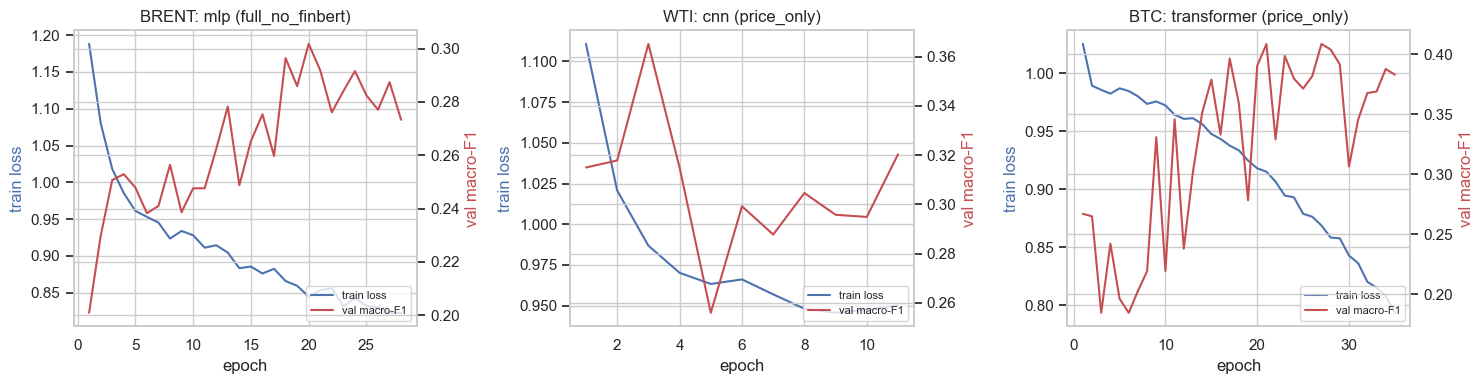

In [8]:
def best_per_asset(experiments):
    by_asset = {}
    for r in experiments:
        a = r.name.split("/")[0]
        if a not in by_asset or r.macro_f1 > by_asset[a].macro_f1:
            by_asset[a] = r
    return by_asset

best_dl = best_per_asset(dl_experiments)
fig, axes = plt.subplots(1, len(best_dl), figsize=(5 * len(best_dl), 4), sharey=False)
if len(best_dl) == 1:
    axes = [axes]
for ax, (k, r) in zip(axes, best_dl.items()):
    epochs = range(1, len(r.train_loss_curve) + 1)
    ax2 = ax.twinx()
    l1, = ax.plot(epochs, r.train_loss_curve, color="C0", label="train loss")
    l2, = ax2.plot(epochs, r.val_f1_curve, color="C3", label="val macro-F1")
    ax.set_xlabel("epoch")
    ax.set_ylabel("train loss", color="C0")
    ax2.set_ylabel("val macro-F1", color="C3")
    ax.set_title(f"{k.upper()}: {r.name.split('/')[-1]} ({r.name.split('/')[1]})")
    ax.legend(handles=[l1, l2], loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

## 8. Общий бенчмарк: baseline -> ML -> DL

Сводим лучшие модели каждого чекпойнта в один график. Цифры чекпоинт 3/чекпоинт 5
берём прямым перерасчётом (на тех же данных, что и DL), чтобы все
макро-F1 были на одном тестовом окне ≥ 2024-01-01.

In [ ]:
from src.models.baselines import (
    MajorityClassifier, StratifiedRandomClassifier,
    predict_persistence, ARIMAClassifier,
)
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

def build_xy_strings(df, feature_cols):
    cols = [c for c in feature_cols if c in df.columns]
    sub = df[cols + ["target"]].dropna()
    Xtr = sub.loc[sub.index < SPLIT_DATE, cols]
    Xte = sub.loc[sub.index >= SPLIT_DATE, cols]
    ytr = sub.loc[sub.index < SPLIT_DATE, "target"]
    yte = sub.loc[sub.index >= SPLIT_DATE, "target"]
    return Xtr, Xte, ytr, yte

bench_rows = []
for k in datasets:
    df = datasets[k]
    # ---- baseline (чекпоинт 3) ----
    Xtr, Xte, ytr, yte = build_xy_strings(df, BASE_FEATURES)
    bench_rows.append({"asset": k, "stage": "чекпоинт 3", "model": "majority",
                       "macro_f1": score(yte, MajorityClassifier().fit(Xtr, ytr).predict(Xte), "x").macro_f1})
    bench_rows.append({"asset": k, "stage": "чекпоинт 3", "model": "stratrand",
                       "macro_f1": score(yte, StratifiedRandomClassifier(RANDOM_STATE).fit(Xtr, ytr).predict(Xte), "x").macro_f1})
    bench_rows.append({"asset": k, "stage": "чекпоинт 3", "model": "persistence",
                       "macro_f1": score(yte, predict_persistence(ytr, yte), "x").macro_f1})
    knn = Pipeline([("s", StandardScaler()),
                    ("m", KNeighborsClassifier(n_neighbors=51, weights="distance", n_jobs=-1))]).fit(Xtr, ytr)
    bench_rows.append({"asset": k, "stage": "чекпоинт 3", "model": "knn",
                       "macro_f1": score(yte, knn.predict(Xte), "x").macro_f1})
    lr = Pipeline([("s", StandardScaler()),
                   ("m", LogisticRegression(C=1.0, max_iter=1000, solver="lbfgs", n_jobs=-1))]).fit(Xtr, ytr)
    bench_rows.append({"asset": k, "stage": "чекпоинт 3", "model": "logreg",
                       "macro_f1": score(yte, lr.predict(Xte), "x").macro_f1})

    # ---- чекпоинт 5 best ML ----
    # Используем full-no-finbert
    Xtr2, Xte2, ytr2, yte2 = build_xy_strings(df, FEAT_SETS["full_no_finbert"])
    if len(Xtr2) > 100:
        ytr2_e = le.transform(ytr2)
        rf = RandomForestClassifier(n_estimators=400, max_depth=8, min_samples_leaf=10,
                                     class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)
        rf.fit(Xtr2, ytr2_e)
        bench_rows.append({"asset": k, "stage": "чекпоинт 5", "model": "RF",
                           "macro_f1": score(yte2, le.inverse_transform(rf.predict(Xte2)), "x").macro_f1})
        hgbt = HistGradientBoostingClassifier(max_depth=6, learning_rate=0.05,
                                              max_iter=300, class_weight="balanced",
                                              random_state=RANDOM_STATE)
        hgbt.fit(Xtr2, ytr2_e)
        bench_rows.append({"asset": k, "stage": "чекпоинт 5", "model": "HGBT",
                           "macro_f1": score(yte2, le.inverse_transform(hgbt.predict(Xte2)), "x").macro_f1})
        lgbm = LGBMClassifier(n_estimators=400, num_leaves=31, learning_rate=0.05,
                              class_weight="balanced", random_state=RANDOM_STATE, verbose=-1)
        lgbm.fit(Xtr2, ytr2_e)
        bench_rows.append({"asset": k, "stage": "чекпоинт 5", "model": "LGBM",
                           "macro_f1": score(yte2, le.inverse_transform(lgbm.predict(Xte2)), "x").macro_f1})

# ---- чекпоинт 6 (DL) - лучшие из dl_experiments ----
for r in dl_experiments:
    asset, feat_set, mdl = r.name.split("/")
    bench_rows.append({"asset": asset, "stage": "чекпоинт 6 (DL)", "model": f"{mdl}({feat_set})",
                       "macro_f1": r.macro_f1})

bench_df = pd.DataFrame(bench_rows)
bench_df["macro_f1"] = bench_df["macro_f1"].astype(float).round(4)

# Топ по каждому активу
for k in datasets:
    print(f"\n=== {k.upper()} (топ-10) ===")
    print(bench_df[bench_df["asset"] == k]
          .sort_values("macro_f1", ascending=False).head(10)
          .to_string(index=False))


=== BRENT (топ-10) ===
asset  stage                   model  macro_f1
brent    чекпоинт 3               stratrand    0.3205
brent чекпоинт 6 (DL)    mlp(full_no_finbert)    0.3172
brent    чекпоинт 3             persistence    0.3166
brent    чекпоинт 5                    HGBT    0.3157
brent чекпоинт 6 (DL)         cnn(price_only)    0.3148
brent чекпоинт 6 (DL)    cnn(full_no_finbert)    0.3127
brent чекпоинт 6 (DL)         mlp(price_only)    0.3024
brent    чекпоинт 5                    LGBM    0.3004
brent чекпоинт 6 (DL) transformer(price_only)    0.2925
brent    чекпоинт 5                      RF    0.2550

=== WTI (топ-10) ===
asset  stage                   model  macro_f1
  wti    чекпоинт 5                      RF    0.3409
  wti    чекпоинт 5                    HGBT    0.3341
  wti    чекпоинт 5                    LGBM    0.3255
  wti    чекпоинт 3             persistence    0.3243
  wti чекпоинт 6 (DL)         cnn(price_only)    0.3170
  wti    чекпоинт 3               stra

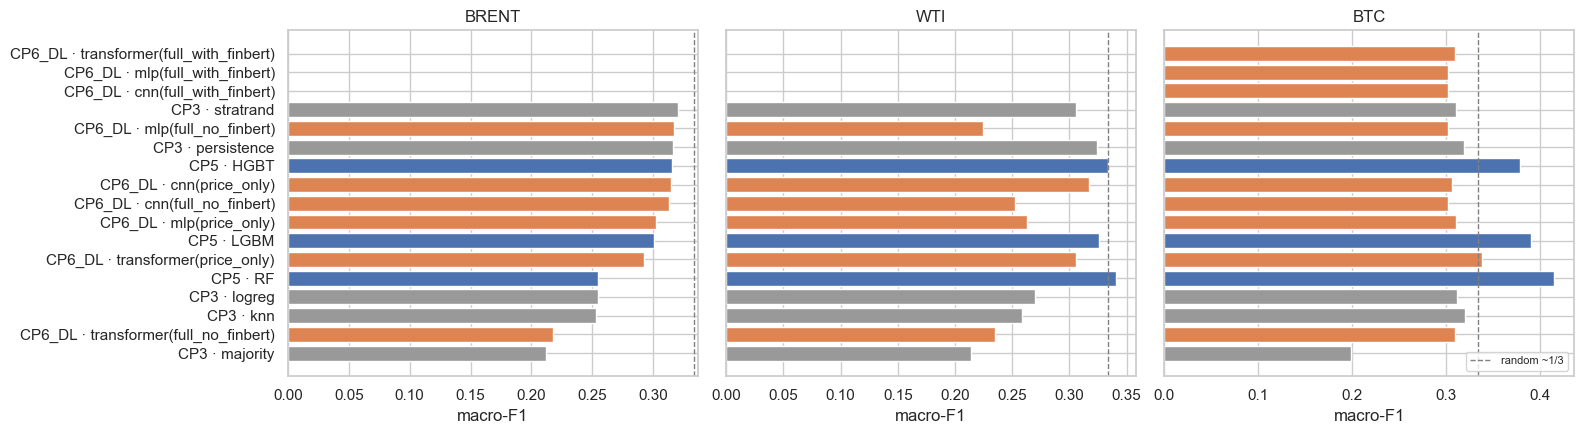

In [ ]:
# победители всех чекпойнтов на графике
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
stage_color = {"чекпоинт 3": "#999999", "чекпоинт 5": "#4c72b0", "чекпоинт 6 (DL)": "#dd8452"}

for ax, k in zip(axes, datasets.keys()):
    sub = bench_df[bench_df["asset"] == k].copy()
    sub["label"] = sub["stage"] + " · " + sub["model"]
    sub = sub.sort_values("macro_f1")
    colors = [stage_color[s] for s in sub["stage"].values]
    ax.barh(sub["label"], sub["macro_f1"], color=colors)
    ax.axvline(1/3, color="grey", ls="--", lw=1, label="random ~1/3")
    ax.set_title(k.upper())
    ax.set_xlabel("macro-F1")
axes[-1].legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

In [11]:
# Топ-3 победителя по каждому активу - таблица
winners = (bench_df.sort_values(["asset", "macro_f1"], ascending=[True, False])
                   .groupby("asset").head(3)
                   .reset_index(drop=True))
winners

,asset,stage,model,macro_f1
0,brent,чекпоинт 3,stratrand,0.3205
1,brent,чекпоинт 6 (DL),mlp(full_no_finbert),0.3172
2,brent,чекпоинт 3,persistence,0.3166
3,btc,чекпоинт 5,RF,0.4152
4,btc,чекпоинт 5,LGBM,0.3900
5,btc,чекпоинт 5,HGBT,0.3789
6,wti,чекпоинт 5,RF,0.3409
7,wti,чекпоинт 5,HGBT,0.3341
8,wti,чекпоинт 5,LGBM,0.3255


## 9. Выводы по чекпоинту

### Что видно по сводной таблице (топ-3 по каждому активу)

**Brent.** Лучший результат - stratified random baseline из чекпоинта 3
(macro-F1 = 0.32). В топ-3 попали `mlp(full_no_finbert)` из чекпоинта 6
(0.3172) и persistence (0.3166). Разброс топ-3 укладывается в 0.005, и
ни одна обученная модель - ни бустинги чекпоинта 5, ни DL чекпоинта 6 -
не пробивает уровень случайного прогноза, размеченного по частотам train.

**WTI.** Топ-3 целиком из чекпоинта 5: `RF` 0.3409, `HGBT` 0.3341,
`LGBM` 0.3255. Прирост лучшего над random ≈ +0.035 macro-F1 - есть
небольшой устойчивый сигнал, который ловят tree-ensembles. DL и CP3
baseline ниже.

**BTC.** Тоже все три места - чекпоинт 5: `RF` 0.4152, `LGBM` 0.3900,
`HGBT` 0.3789. Прирост над random ≈ +0.10 - заметно больше, чем на нефти.
Это согласуется с тем, что BTC сильнее реагирует на новостной поток
(текстовые лаги дают вклад) и что у нас по BTC примерно вдвое больше
обучающих примеров (24/7 vs торговый календарь).

### Почему DL не выиграл

1. **Объём данных.** ~1500-2500 строк дневной истории - слишком мало для
   рекуррентных и attention-моделей. Tree-ensembles с регуляризацией
   глубины (RF max_depth=8, HGBT max_depth=6) на таком масштабе ведут
   себя лучше: меньше переобучения, меньше зависимости от seed.
   Sebastião & Godinho (2021), §5 приходят к тому же выводу: на дневной
   частоте без альтернативных источников данных DL ≈ ML.

2. **Качество текста ограничивает потолок.** GDELT-tone - это
   WordNet-словарь, эвристика. Прирост от его подключения уже
   зафиксирован в чекпоинте 5 как ~+0.02-0.03 macro-F1. Hashamia &
   Maldonado (2025) показывают, что **основной gain** даёт переход к
   доменно-настроенному sentiment'у (CrudeBERT). Без него потолок
   и для ML, и для DL одинаковый.

3. **Класс `flat` слабый у всех.** F1_flat лучших моделей не превышает
   ~0.3 (и это только на BTC, где flat ловит RF). На нефти `flat`
   практически невидим. "Безразличный день" - это отсутствие сигнала,
   а отсутствие труднее зафиксировать как фичу.

### Что бы сделали дальше

1. **Fine-tune CrudeBERT** (Kaplan et al., 2023,
   [arXiv:2305.06140](https://arxiv.org/abs/2305.06140))
   на размеченных по supply/demand новостях нефти. На Brent сейчас
   неработает ни одна модель - именно здесь это потенциально
   разблокировало бы сигнал.

2. **Полный исторический корпус статей** для FinBERT. Сейчас
   FinBERT-фича доступна только на 10 датах (квартальные границы 2018-19),
   и в production-модель CP6 она не вошла. Решение - дособрать ArtList
   GDELT по месяцам, не по кварталам.

3. **Dual-stream LSTM с attention** на (`OHLCV`, `text_embedding`)
   как у Ghali et al. (2025,
   [arXiv:2508.06497](https://arxiv.org/abs/2508.06497)). Их AUC 0.94 -
   ориентир при наличии полноценного исторического корпуса.

4. **Intraday-таймфрейм.** Новость влияет на цену в горизонте часов,
   а не дней. На минутных или часовых барах сигнал должен быть сильнее.

5. **Backtest** простой стратегии "long up / short down / flat = пассив"
   с учётом транзакционных издержек. Перевод macro-F1 в Sharpe ratio -
   это то, что в итоге интересует пользователя сервиса.

### Резюме

На WTI и BTC лучший результат даёт **RandomForest на 27 фичах** (цена +
лаги новостей + кластерный режим + cross-asset спред) - около +0.035 и
+0.10 macro-F1 над случайным baseline соответственно. На Brent ни ML,
ни DL не пробивают baseline - это указывает не на слабость моделей,
а на отсутствие сигнала в текущих фичах. DL-архитектуры на нашем
масштабе данных не дают преимущества: для них нужен либо больший
корпус (intraday / multi-asset), либо качественные доменные
sentiment-эмбеддинги (CrudeBERT).
